# Phase-Space Volumes and Chaos

In addition to integrating orbits, galpy can integrate the *variational
equations*: the linearized equations of motion that govern how an
infinitesimal phase-space displacement $\delta x$ evolves along an orbit. This
is done with the `Orbit.integrate_dxdv` method, which works for
two-dimensional (planar) and, since version 1.12, fully three-dimensional
orbits, and is implemented in C for most potentials for speed.

Integrating deviation vectors gives access to the *state-transition matrix*
$M(t) = \partial x(t)/\partial x(0)$, whose columns are the evolved
phase-space basis deviations. This allows you to

* verify **Liouville's theorem** ($\det M = 1$: phase-space volume is conserved),
* quantify the **sensitivity** of an orbit to its initial conditions, and
* compute **Lyapunov exponents** to detect chaos, using the
  `Orbit.lyapunov` method built on top of `integrate_dxdv`.

This tutorial briefly demonstrates each of these.

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy

from galpy.orbit import Orbit
from galpy.potential import HenonHeilesPotential, MWPotential2014, toPlanarPotential

## Integrating phase-space deviations in 2D

For a planar orbit, the phase-space deviation is the four-vector
$\delta x = (\delta x, \delta y, \delta v_x, \delta v_y)$ in *rectangular*
coordinates (use `rectIn=True`/`rectOut=True` to work entirely in this basis;
otherwise galpy converts from/to cylindrical deviations). `integrate_dxdv`
propagates the deviation with the linearized dynamics along the orbit; the
deviation as a function of time is accessed with `getOrbit_dxdv`.

Integrating the four basis deviations builds up the state-transition matrix
$M(t)$, and Liouville's theorem says that $\det M(t) = 1$ at all times:

max |det M - 1| = 7.5e-07


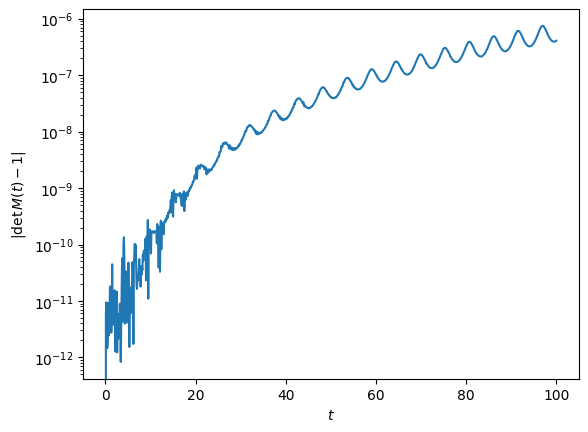

In [2]:
mw2d = toPlanarPotential(MWPotential2014)
ts = numpy.linspace(0.0, 100.0, 1001)
M = numpy.empty((len(ts), 4, 4))
for ii in range(4):
    dxdv = numpy.zeros(4)
    dxdv[ii] = 1.0
    o = Orbit([1.0, 0.1, 1.1, 0.0])
    o.integrate_dxdv(dxdv, ts, mw2d, method="dop853_c", rectIn=True, rectOut=True)
    M[:, :, ii] = o.getOrbit_dxdv()
detM = numpy.linalg.det(M)
plt.semilogy(ts, numpy.fabs(detM - 1.0))
plt.xlabel(r"$t$")
plt.ylabel(r"$|\det M(t) - 1|$")
print(f"max |det M - 1| = {numpy.amax(numpy.fabs(detM - 1.0)):.2g}")

Phase-space volume is conserved to high precision (set by the integration
tolerances) over the whole integration.

## ... and in 3D

For three-dimensional orbits, everything works the same with the six-vector
$\delta x = (\delta x, \delta y, \delta z, \delta v_x, \delta v_y, \delta
v_z)$ and the $6\times6$ state-transition matrix; the full 3D Hessian of the
potential is implemented in C for most potentials:

max |det M - 1| = 1.1e-07


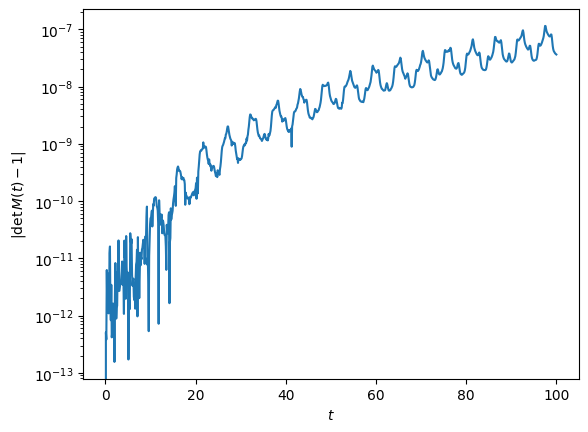

In [3]:
ts = numpy.linspace(0.0, 100.0, 1001)
M = numpy.empty((len(ts), 6, 6))
for ii in range(6):
    dxdv = numpy.zeros(6)
    dxdv[ii] = 1.0
    o = Orbit([1.0, 0.1, 1.1, 0.0, 0.1, 0.0])
    o.integrate_dxdv(
        dxdv,
        ts,
        MWPotential2014,
        method="dop853_c",
        rectIn=True,
        rectOut=True,
        rtol=1e-12,
        atol=1e-12,
    )
    M[:, :, ii] = o.getOrbit_dxdv()
detM = numpy.linalg.det(M)
plt.semilogy(ts, numpy.fabs(detM - 1.0))
plt.xlabel(r"$t$")
plt.ylabel(r"$|\det M(t) - 1|$")
print(f"max |det M - 1| = {numpy.amax(numpy.fabs(detM - 1.0)):.2g}")

## Lyapunov exponents and chaos

The growth rate of phase-space deviations is the classic diagnostic of chaos:
for a regular orbit, deviations grow as a power of time, while for a chaotic
orbit they grow exponentially, $|\delta x(t)| \sim e^{\lambda t}$, with
$\lambda$ the largest *Lyapunov exponent*. `Orbit.lyapunov` estimates
$\lambda$ using the classic Benettin et al. (1980) method: it propagates a
deviation vector with `integrate_dxdv`, renormalizes it regularly to avoid
overflow, and accumulates the growth factors into the running estimate
$\lambda(t)$, which is returned at all output times so that you can check its
convergence. For a regular orbit, $\lambda(t) \approx \ln(t)/t \rightarrow
0$, while for a chaotic orbit $\lambda(t)$ converges to a positive value.

The Hénon–Heiles potential is the classic example of a system with a mix of
regular and chaotic orbits. Here we compute the running Lyapunov estimate for
a well-known chaotic and a well-known regular orbit at energy $E = 1/8$
(orbits F and E of [Skokos et al. 2002](https://arxiv.org/abs/nlin/0210053)):

chaotic:  lambda = 0.055
regular:  lambda = 0.00027


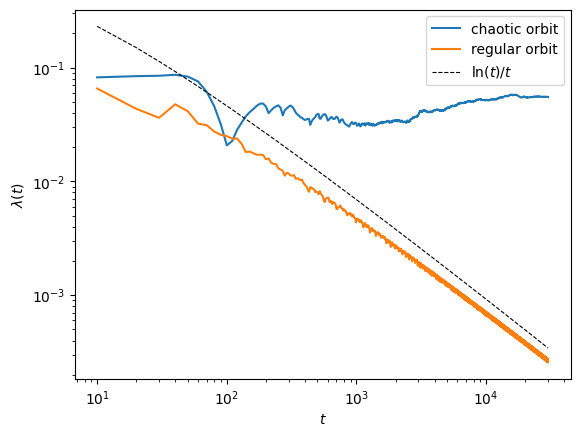

In [4]:
hp = HenonHeilesPotential()
ts = numpy.linspace(0.0, 30000.0, 3001)
o_chaotic = Orbit([0.016, 0.0, 0.49974, -numpy.pi / 2.0])
lam_chaotic = o_chaotic.lyapunov(ts, pot=hp, method="dop853_c")
o_regular = Orbit([0.55, 0.0, -0.2417, numpy.pi / 2.0])
lam_regular = o_regular.lyapunov(ts, pot=hp, method="dop853_c")
plt.loglog(ts[1:], lam_chaotic[1:], label="chaotic orbit")
plt.loglog(ts[1:], lam_regular[1:], label="regular orbit")
plt.loglog(ts[1:], numpy.log(ts[1:]) / ts[1:], "k--", lw=0.8, label=r"$\ln(t)/t$")
plt.xlabel(r"$t$")
plt.ylabel(r"$\lambda(t)$")
plt.legend()
print(f"chaotic:  lambda = {lam_chaotic[-1]:.3f}")
print(f"regular:  lambda = {lam_regular[-1]:.2g}")

The chaotic orbit's estimate converges to $\lambda \approx 0.05$ (consistent
with the literature value for this orbit, e.g., Benettin et al. 1976), while
the regular orbit's estimate decays as $\ln(t)/t$, the signature of
regularity.

`lyapunov` works for three-dimensional orbits in the same way and supports
physical outputs: when the orbit and potential carry physical scales, the
returned exponent is in $\mathrm{Gyr}^{-1}$ (it is a frequency). For example,
for a mildly perturbed disk orbit in `MWPotential2014` (a regular orbit, so
the estimate decays):

In [5]:
o = Orbit([1.0, 0.1, 1.1, 0.0, 0.1, 0.0], ro=8.0, vo=220.0)
ts = numpy.linspace(0.0, 1000.0, 101)
lam = o.lyapunov(ts, pot=MWPotential2014, method="dop853_c", renorm_every=5)
print(f"lambda(t_mid) = {lam[len(ts) // 2]:.2f}, lambda(t_end) = {lam[-1]:.2f}")
print("(decreasing -> consistent with a regular orbit; convergence to zero")
print(" requires much longer integration times)")

lambda(t_mid) = 1.18, lambda(t_end) = 1.06
(decreasing -> consistent with a regular orbit; convergence to zero
 requires much longer integration times)


For more details, see the API documentation of
[Orbit.integrate_dxdv](../../reference/orbitintdxdv.rst),
[Orbit.getOrbit_dxdv](../../reference/orbitgetorbitdxdv.rst), and
[Orbit.lyapunov](../../reference/orbitlyapunov.rst).